# PASO 3: Baseline 2 - Predicción de Tardanza por Segmento Histórico

**Objetivo:** Construir un baseline probabilístico que predice `Late_delivery_risk` usando tasas históricas por segmento (Shipping Mode + Order Region).

**Por qué este baseline:**
- Es el rival a superar para cualquier modelo de ML
- Captura patrones reales del negocio sin overfitting
- Usa información disponible al momento del despacho

**No incluye:** Modelos de ML, feature engineering complejo, ni optimización de hiperparámetros.

## 1. Imports y Configuración

Carga de librerías para manipulación de datos, evaluación de métricas y visualización.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    precision_recall_curve, 
    auc, 
    precision_score, 
    recall_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ Librerías cargadas')

✓ Librerías cargadas


## 2. Carga de Datos

Intentar cargar el dataset limpio del Paso 2. Si no existe, usar el dataset original con filtro mínimo.

In [2]:
# Intentar cargar dataset limpio del Paso 2
data_dir = Path('../data')
clean_path = data_dir / 'processed' / 'DataCoSupplyChainDataset_clean.csv'
original_path = data_dir / 'csv' / 'DataCoSupplyChainDataset.csv'

if clean_path.exists():
    print(f'✓ Cargando dataset limpio: {clean_path.name}')
    df = pd.read_csv(clean_path)
    using_clean = True
else:
    print(f'⚠️ Dataset limpio no encontrado. Usando dataset original.')
    df = pd.read_csv(original_path, encoding='latin-1')
    using_clean = False

# Estandarizar nombres de columnas
df.columns = df.columns.str.replace(' ', '_', regex=False)

print(f'\nDataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Fuente: {"DataCoSupplyChainDataset_clean.csv" if using_clean else "DataCoSupplyChainDataset.csv (original)"}')

✓ Cargando dataset limpio: DataCoSupplyChainDataset_clean.csv

Dataset cargado: 180,519 filas × 35 columnas
Fuente: DataCoSupplyChainDataset_clean.csv


## 3. Validación de Columnas Requeridas

Verificar que existan las columnas necesarias para el baseline.

In [3]:
# Columnas requeridas
required_cols = [
    'Late_delivery_risk',
    'Delivery_Status',
    'Shipping_Mode',
    'Order_Region',
    'Market',
    'shipping_date_(DateOrders)'
]

print('=== VALIDACIÓN DE COLUMNAS REQUERIDAS ===\n')
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f'❌ Columnas faltantes: {missing_cols}')
    print(f'\nColumnas disponibles en el dataset:')
    print(df.columns.tolist())
    raise ValueError('Faltan columnas requeridas para el baseline')
else:
    print('✓ Todas las columnas requeridas están presentes')
    for col in required_cols:
        print(f'  - {col}: {df[col].dtype}, {df[col].nunique()} valores únicos')

=== VALIDACIÓN DE COLUMNAS REQUERIDAS ===

✓ Todas las columnas requeridas están presentes
  - Late_delivery_risk: int64, 2 valores únicos
  - Delivery_Status: object, 4 valores únicos
  - Shipping_Mode: object, 4 valores únicos
  - Order_Region: object, 23 valores únicos
  - Market: object, 5 valores únicos
  - shipping_date_(DateOrders): object, 63701 valores únicos


## 4. Parseo de Fecha de Despacho

Convertir `shipping_date_(DateOrders)` a datetime para permitir ordenamiento temporal.

In [4]:
print('=== PARSEO DE FECHA ===\n')

# Parsear shipping_date
df['shipping_date_(DateOrders)'] = pd.to_datetime(df['shipping_date_(DateOrders)'], errors='coerce')

# Verificar parseo
nulos_fecha = df['shipping_date_(DateOrders)'].isna().sum()
pct_exitoso = (len(df) - nulos_fecha) / len(df) * 100

print(f'Parseo exitoso: {len(df) - nulos_fecha:,} / {len(df):,} ({pct_exitoso:.2f}%)')
print(f'Fecha mínima: {df["shipping_date_(DateOrders)"].min()}')
print(f'Fecha máxima: {df["shipping_date_(DateOrders)"].max()}')
print(f'Rango: {(df["shipping_date_(DateOrders)"].max() - df["shipping_date_(DateOrders)"].min()).days} días')

# Eliminar filas sin fecha válida
if nulos_fecha > 0:
    print(f'\n⚠️ Eliminando {nulos_fecha:,} filas sin fecha válida')
    df = df.dropna(subset=['shipping_date_(DateOrders)'])
    
print(f'\n✓ Dataset con fechas válidas: {len(df):,} filas')

=== PARSEO DE FECHA ===

Parseo exitoso: 180,519 / 180,519 (100.00%)
Fecha mínima: 2015-01-03 00:00:00
Fecha máxima: 2018-02-06 22:14:00
Rango: 1130 días

✓ Dataset con fechas válidas: 180,519 filas


## 5. Filtro de Universo

Excluir envíos cancelados (`Delivery_Status == "Shipping canceled"`). Estos no son tardanzas, son cancelaciones.

In [5]:
print('=== FILTRO DE UNIVERSO ===\n')
print(f'Filas antes del filtro: {len(df):,}')

# Mostrar distribución de Delivery_Status
print('\nDistribución de Delivery_Status:')
for status, count in df['Delivery_Status'].value_counts().items():
    pct = count / len(df) * 100
    print(f'  {status:25s}: {count:>7,} ({pct:>5.2f}%)')

# Aplicar filtro
df = df[~df['Delivery_Status'].str.contains('cancel', case=False, na=False)].copy()

print(f'\n✓ Filas después de excluir cancelados: {len(df):,}')
print(f'  Reducción: {df.shape[0]} filas')

=== FILTRO DE UNIVERSO ===

Filas antes del filtro: 180,519

Distribución de Delivery_Status:
  Late delivery            :  98,977 (54.83%)
  Advance shipping         :  41,592 (23.04%)
  Shipping on time         :  32,196 (17.84%)
  Shipping canceled        :   7,754 ( 4.30%)

✓ Filas después de excluir cancelados: 172,765
  Reducción: 172765 filas


## 6. Verificación del Target

Validar balance de clases y valores del target `Late_delivery_risk`.

In [6]:
print('=== VERIFICACIÓN DEL TARGET ===\n')

# Distribución del target
target_counts = df['Late_delivery_risk'].value_counts().sort_index()
target_pcts = df['Late_delivery_risk'].value_counts(normalize=True).sort_index() * 100

print('Distribución de Late_delivery_risk:')
for val in target_counts.index:
    label = 'TARDE' if val == 1 else 'A TIEMPO'
    print(f'  {val} ({label:8s}): {target_counts[val]:>7,} ({target_pcts[val]:>5.2f}%)')

# Balance
balance_ratio = target_counts.min() / target_counts.max()
print(f'\nBalance ratio: {balance_ratio:.3f}')

# Nulos
nulos_target = df['Late_delivery_risk'].isna().sum()
if nulos_target > 0:
    print(f'\n⚠️ Eliminando {nulos_target:,} filas con target nulo')
    df = df.dropna(subset=['Late_delivery_risk'])

print(f'\n✓ Dataset final para baseline: {len(df):,} filas')

=== VERIFICACIÓN DEL TARGET ===

Distribución de Late_delivery_risk:
  0 (A TIEMPO):  73,788 (42.71%)
  1 (TARDE   ):  98,977 (57.29%)

Balance ratio: 0.746

✓ Dataset final para baseline: 172,765 filas


## 7. Split Temporal (Train/Test)

Particionar el dataset por fecha de despacho: 80% más antiguo para train, 20% más reciente para test.

In [7]:
print('=== SPLIT TEMPORAL ===\n')

# Ordenar por fecha
df_sorted = df.sort_values('shipping_date_(DateOrders)').reset_index(drop=True)

# Calcular punto de corte (80/20)
split_idx = int(len(df_sorted) * 0.8)

print(f'Total registros: {len(df_sorted):,}')
print(f'Punto de corte: índice {split_idx:,}')

# Dividir train/test
train = df_sorted.iloc[:split_idx].copy()
test = df_sorted.iloc[split_idx:].copy()

print(f'\n📊 TRAIN SET:')
print(f'   Filas: {len(train):,} ({len(train)/len(df_sorted)*100:.1f}%)')
print(f'   Fecha min: {train["shipping_date_(DateOrders)"].min().date()}')
print(f'   Fecha max: {train["shipping_date_(DateOrders)"].max().date()}')
print(f'   Tardanzas: {train["Late_delivery_risk"].sum():,} ({train["Late_delivery_risk"].mean()*100:.2f}%)')

print(f'\n📊 TEST SET:')
print(f'   Filas: {len(test):,} ({len(test)/len(df_sorted)*100:.1f}%)')
print(f'   Fecha min: {test["shipping_date_(DateOrders)"].min().date()}')
print(f'   Fecha max: {test["shipping_date_(DateOrders)"].max().date()}')
print(f'   Tardanzas: {test["Late_delivery_risk"].sum():,} ({test["Late_delivery_risk"].mean()*100:.2f}%)')

print('\n✓ Split temporal completado')

=== SPLIT TEMPORAL ===

Total registros: 172,765
Punto de corte: índice 138,212

📊 TRAIN SET:
   Filas: 138,212 (80.0%)
   Fecha min: 2015-01-03
   Fecha max: 2017-04-25
   Tardanzas: 79,130 (57.25%)

📊 TEST SET:
   Filas: 34,553 (20.0%)
   Fecha min: 2017-04-25
   Fecha max: 2018-02-06
   Tardanzas: 19,847 (57.44%)

✓ Split temporal completado


## 8. Baseline 2: Cálculo de Tasas por Segmento

Calcular tasas históricas de tardanza en TRAIN por grupo (Shipping_Mode, Order_Region).

In [8]:
print('=== CÁLCULO DE TASAS POR SEGMENTO (BASELINE 2) ===\n')

# Calcular tasas por grupo (Shipping_Mode, Order_Region)
group_rates = train.groupby(['Shipping_Mode', 'Order_Region'])['Late_delivery_risk'].agg([
    ('total_envios', 'count'),
    ('total_tarde', 'sum'),
    ('tasa_tardanza', 'mean')
]).reset_index()

# Ordenar por cantidad de envíos
group_rates = group_rates.sort_values('total_envios', ascending=False)

print(f'Total de grupos (Shipping_Mode × Order_Region): {len(group_rates)}')
print(f'\nTop 10 grupos por volumen:\n')
print(group_rates.head(10).to_string(index=False))

# Calcular fallbacks
print('\n' + '='*60)
print('FALLBACKS (para grupos no vistos en train):')
print('='*60)

# Fallback 1: tasas por Shipping_Mode solamente
mode_rates = train.groupby('Shipping_Mode')['Late_delivery_risk'].agg([
    ('total_envios', 'count'),
    ('tasa_tardanza', 'mean')
]).reset_index()

print(f'\n1. Tasas por Shipping_Mode (fallback nivel 1):')
print(mode_rates.to_string(index=False))

# Fallback 2: tasa global
global_rate = train['Late_delivery_risk'].mean()
print(f'\n2. Tasa global (fallback nivel 2): {global_rate:.4f}')

print('\n✓ Tasas calculadas en TRAIN')

=== CÁLCULO DE TASAS POR SEGMENTO (BASELINE 2) ===

Total de grupos (Shipping_Mode × Order_Region): 92

Top 10 grupos por volumen:

 Shipping_Mode    Order_Region  total_envios  total_tarde  tasa_tardanza
Standard Class Central America         13203         5255         0.3980
Standard Class  Western Europe          8230         3379         0.4106
Standard Class   South America          6879         2735         0.3976
Standard Class         Oceania          5093         2069         0.4062
Standard Class    West of USA           4548         1782         0.3918
Standard Class  Southeast Asia          4465         1822         0.4081
  Second Class Central America          4344         3392         0.7808
Standard Class       Caribbean          4008         1457         0.3635
Standard Class     East of USA          3948         1643         0.4162
Standard Class      South Asia          3710         1479         0.3987

FALLBACKS (para grupos no vistos en train):

1. Tasas por Shippi

## 9. Scoring en Test con Fallback

Asignar score predicho a cada fila de TEST según su grupo. Aplicar fallback si el grupo no existe en TRAIN.

In [9]:
print('=== SCORING EN TEST ===\n')

# Crear diccionario de tasas por grupo para lookup rápido
group_dict = group_rates.set_index(['Shipping_Mode', 'Order_Region'])['tasa_tardanza'].to_dict()
mode_dict = mode_rates.set_index('Shipping_Mode')['tasa_tardanza'].to_dict()

# Función de scoring con fallback
def get_score(row):
    # Nivel 1: grupo exacto
    key = (row['Shipping_Mode'], row['Order_Region'])
    if key in group_dict:
        return group_dict[key]
    
    # Nivel 2: solo Shipping_Mode
    if row['Shipping_Mode'] in mode_dict:
        return mode_dict[row['Shipping_Mode']]
    
    # Nivel 3: tasa global
    return global_rate

# Aplicar scoring
test['score_pred'] = test.apply(get_score, axis=1)

# Estadísticas de uso de fallback
grupos_test = test[['Shipping_Mode', 'Order_Region']].drop_duplicates()
fallback_stats = {
    'nivel_1_grupo': 0,
    'nivel_2_mode': 0,
    'nivel_3_global': 0
}

for _, row in grupos_test.iterrows():
    key = (row['Shipping_Mode'], row['Order_Region'])
    if key in group_dict:
        fallback_stats['nivel_1_grupo'] += 1
    elif row['Shipping_Mode'] in mode_dict:
        fallback_stats['nivel_2_mode'] += 1
    else:
        fallback_stats['nivel_3_global'] += 1

print(f'Grupos únicos en TEST: {len(grupos_test)}')
print(f'\nUso de fallback:')
print(f'  Nivel 1 (grupo exacto):      {fallback_stats["nivel_1_grupo"]} grupos')
print(f'  Nivel 2 (solo Shipping_Mode): {fallback_stats["nivel_2_mode"]} grupos')
print(f'  Nivel 3 (tasa global):        {fallback_stats["nivel_3_global"]} grupos')

print(f'\nDistribución de scores predichos en TEST:')
print(f'  Min:    {test["score_pred"].min():.4f}')
print(f'  Max:    {test["score_pred"].max():.4f}')
print(f'  Media:  {test["score_pred"].mean():.4f}')
print(f'  Mediana: {test["score_pred"].median():.4f}')

print('\n✓ Scoring completado en TEST')

=== SCORING EN TEST ===

Grupos únicos en TEST: 40

Uso de fallback:
  Nivel 1 (grupo exacto):      40 grupos
  Nivel 2 (solo Shipping_Mode): 0 grupos
  Nivel 3 (tasa global):        0 grupos

Distribución de scores predichos en TEST:
  Min:    0.3309
  Max:    1.0000
  Media:  0.5717
  Mediana: 0.4106

✓ Scoring completado en TEST


## 10. Evaluación: PR-AUC

Calcular el área bajo la curva Precision-Recall (PR-AUC) para el baseline en TEST.

=== EVALUACIÓN: PR-AUC ===

PR-AUC (Baseline 2 en TEST): 0.8368


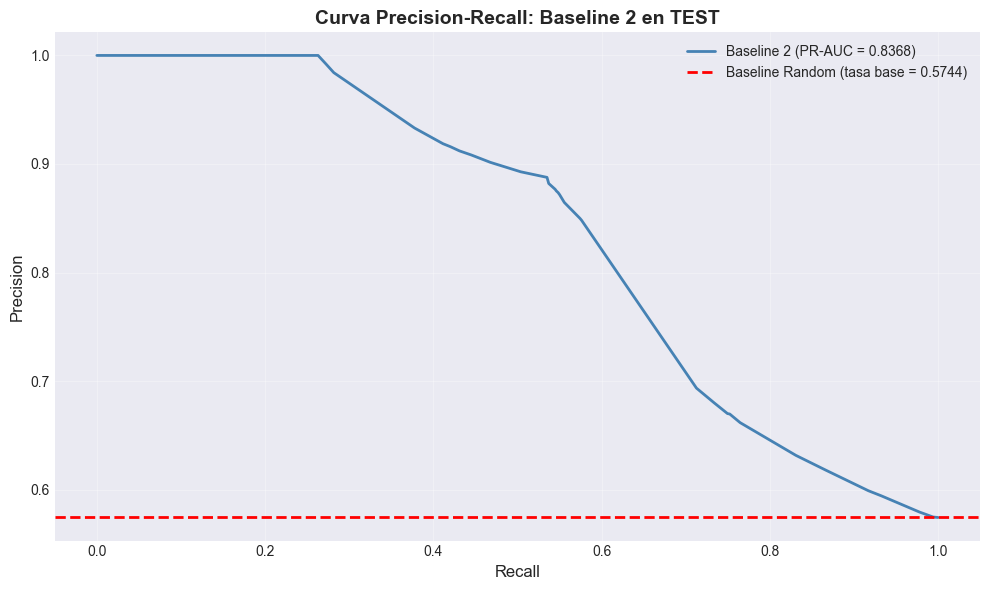


✓ PR-AUC calculado


In [10]:
print('=== EVALUACIÓN: PR-AUC ===\n')

# Calcular curva PR
precision, recall, thresholds = precision_recall_curve(
    test['Late_delivery_risk'], 
    test['score_pred']
)

# Calcular PR-AUC
pr_auc = auc(recall, precision)

print(f'PR-AUC (Baseline 2 en TEST): {pr_auc:.4f}')

# Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(recall, precision, linewidth=2, label=f'Baseline 2 (PR-AUC = {pr_auc:.4f})', color='steelblue')
ax.axhline(test['Late_delivery_risk'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f'Baseline Random (tasa base = {test["Late_delivery_risk"].mean():.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Curva Precision-Recall: Baseline 2 en TEST', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n✓ PR-AUC calculado')

## 11. Evaluación: Precision y Recall en Umbrales Predefinidos

Evaluar el baseline usando dos umbrales fijos:
- **Umbral 0.5**: clasificación estándar
- **Top 20% scores**: simulando un sistema de alertas que marca el 20% con mayor riesgo

In [11]:
print('=== EVALUACIÓN: PRECISION Y RECALL EN UMBRALES ===\n')

# Umbral 1: 0.5 (estándar)
threshold_50 = 0.5
pred_50 = (test['score_pred'] >= threshold_50).astype(int)

precision_50 = precision_score(test['Late_delivery_risk'], pred_50)
recall_50 = recall_score(test['Late_delivery_risk'], pred_50)

print(f'📌 UMBRAL = {threshold_50}:')
print(f'   Precision (clase TARDE): {precision_50:.4f}')
print(f'   Recall (clase TARDE):    {recall_50:.4f}')
print(f'   Alertas generadas:       {pred_50.sum():,} ({pred_50.sum()/len(test)*100:.2f}%)')

# Umbral 2: Top 20% (percentil 80)
threshold_p80 = test['score_pred'].quantile(0.80)
pred_p80 = (test['score_pred'] >= threshold_p80).astype(int)

precision_p80 = precision_score(test['Late_delivery_risk'], pred_p80)
recall_p80 = recall_score(test['Late_delivery_risk'], pred_p80)

print(f'\n📌 UMBRAL = Top 20% (score >= {threshold_p80:.4f}):')
print(f'   Precision (clase TARDE): {precision_p80:.4f}')
print(f'   Recall (clase TARDE):    {recall_p80:.4f}')
print(f'   Alertas generadas:       {pred_p80.sum():,} ({pred_p80.sum()/len(test)*100:.2f}%)')

# Matriz de confusión para umbral 0.5
print(f'\n📊 MATRIZ DE CONFUSIÓN (Umbral = {threshold_50}):')
cm = confusion_matrix(test['Late_delivery_risk'], pred_50)
print('\n                Pred: A Tiempo    Pred: Tarde')
print(f'Real: A Tiempo      {cm[0,0]:>10,}    {cm[0,1]:>10,}')
print(f'Real: Tarde         {cm[1,0]:>10,}    {cm[1,1]:>10,}')

print('\n✓ Evaluación en umbrales completada')

=== EVALUACIÓN: PRECISION Y RECALL EN UMBRALES ===

📌 UMBRAL = 0.5:
   Precision (clase TARDE): 0.8751
   Recall (clase TARDE):    0.5464
   Alertas generadas:       12,393 (35.87%)

📌 UMBRAL = Top 20% (score >= 0.8167):
   Precision (clase TARDE): 0.9332
   Recall (clase TARDE):    0.3777
   Alertas generadas:       8,033 (23.25%)

📊 MATRIZ DE CONFUSIÓN (Umbral = 0.5):

                Pred: A Tiempo    Pred: Tarde
Real: A Tiempo          13,158         1,548
Real: Tarde              9,002        10,845

✓ Evaluación en umbrales completada


## 12. Visualización de Distribución de Scores

Comparar la distribución de scores predichos entre la clase "A tiempo" y "Tarde".

=== DISTRIBUCIÓN DE SCORES POR CLASE ===



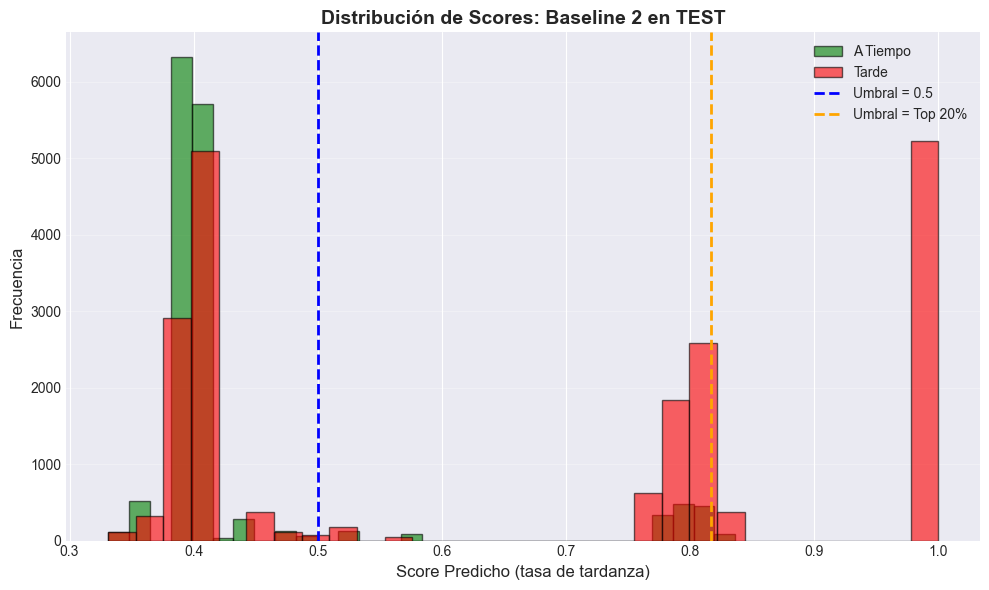

Media score - A Tiempo: 0.4396
Media score - Tarde:    0.6696
Diferencia:             0.2300


In [12]:
print('=== DISTRIBUCIÓN DE SCORES POR CLASE ===\n')

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Histogramas separados por clase
scores_0 = test[test['Late_delivery_risk'] == 0]['score_pred']
scores_1 = test[test['Late_delivery_risk'] == 1]['score_pred']

ax.hist(scores_0, bins=30, alpha=0.6, label='A Tiempo', color='green', edgecolor='black')
ax.hist(scores_1, bins=30, alpha=0.6, label='Tarde', color='red', edgecolor='black')

ax.axvline(threshold_50, color='blue', linestyle='--', linewidth=2, label=f'Umbral = {threshold_50}')
ax.axvline(threshold_p80, color='orange', linestyle='--', linewidth=2, label=f'Umbral = Top 20%')

ax.set_xlabel('Score Predicho (tasa de tardanza)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('Distribución de Scores: Baseline 2 en TEST', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Media score - A Tiempo: {scores_0.mean():.4f}')
print(f'Media score - Tarde:    {scores_1.mean():.4f}')
print(f'Diferencia:             {scores_1.mean() - scores_0.mean():.4f}')

## 13. Guardar Predicciones del Baseline en TEST

Exportar archivo CSV con las predicciones del baseline para auditoría y comparación futura.

In [13]:
print('=== GUARDANDO PREDICCIONES DEL BASELINE ===\n')

# Crear directorio de salida
output_dir = Path('../data/processed')
output_dir.mkdir(parents=True, exist_ok=True)

# Preparar datos para guardar
predictions = test[[
    'shipping_date_(DateOrders)',
    'Shipping_Mode',
    'Order_Region',
    'Late_delivery_risk',
    'score_pred'
]].copy()

# Guardar
pred_path = output_dir / 'baseline2_predictions_test.csv'
predictions.to_csv(pred_path, index=False)

print(f'✓ Predicciones guardadas: {pred_path}')
print(f'  Tamaño: {pred_path.stat().st_size / 1024:.2f} KB')
print(f'  Filas: {len(predictions):,}')
print(f'  Columnas: {predictions.shape[1]}')

=== GUARDANDO PREDICCIONES DEL BASELINE ===

✓ Predicciones guardadas: ..\data\processed\baseline2_predictions_test.csv
  Tamaño: 2298.83 KB
  Filas: 34,553
  Columnas: 5


## 14. Guardar Tasas por Grupo (TRAIN)

Exportar tabla de tasas históricas por segmento calculadas en TRAIN.

In [14]:
print('=== GUARDANDO TASAS POR GRUPO ===\n')

# Guardar tasas por grupo
rates_path = output_dir / 'baseline2_group_rates.csv'
group_rates.to_csv(rates_path, index=False)

print(f'✓ Tasas por grupo guardadas: {rates_path}')
print(f'  Tamaño: {rates_path.stat().st_size / 1024:.2f} KB')
print(f'  Grupos: {len(group_rates):,}')

# También guardar tasas por Shipping_Mode (fallback nivel 1)
mode_rates_path = output_dir / 'baseline2_mode_rates.csv'
mode_rates.to_csv(mode_rates_path, index=False)

print(f'\n✓ Tasas por Shipping_Mode guardadas: {mode_rates_path}')
print(f'  Modos: {len(mode_rates):,}')

=== GUARDANDO TASAS POR GRUPO ===

✓ Tasas por grupo guardadas: ..\data\processed\baseline2_group_rates.csv
  Tamaño: 4.57 KB
  Grupos: 92

✓ Tasas por Shipping_Mode guardadas: ..\data\processed\baseline2_mode_rates.csv
  Modos: 4


---

# RESUMEN FINAL: BASELINE 2

---

In [15]:
print('='*70)
print(' '*15 + 'RESUMEN FINAL - BASELINE 2')
print('='*70)

print('\n📊 PARTICIÓN DE DATOS:')
print(f'   TRAIN: {len(train):,} filas ({len(train)/len(df_sorted)*100:.1f}%)')
print(f'          Período: {train["shipping_date_(DateOrders)"].min().date()} a {train["shipping_date_(DateOrders)"].max().date()}')
print(f'          Tardanzas: {train["Late_delivery_risk"].sum():,} ({train["Late_delivery_risk"].mean()*100:.2f}%)')

print(f'\n   TEST:  {len(test):,} filas ({len(test)/len(df_sorted)*100:.1f}%)')
print(f'          Período: {test["shipping_date_(DateOrders)"].min().date()} a {test["shipping_date_(DateOrders)"].max().date()}')
print(f'          Tardanzas: {test["Late_delivery_risk"].sum():,} ({test["Late_delivery_risk"].mean()*100:.2f}%)')

print('\n🎯 BASELINE CONSTRUIDO:')
print(f'   Tipo: Tasas históricas por segmento')
print(f'   Segmento principal: (Shipping_Mode × Order_Region)')
print(f'   Grupos en TRAIN: {len(group_rates):,}')
print(f'   Fallback nivel 1: Tasas por Shipping_Mode ({len(mode_rates)} modos)')
print(f'   Fallback nivel 2: Tasa global = {global_rate:.4f}')

print('\n📈 MÉTRICAS EN TEST:')
print(f'   PR-AUC: {pr_auc:.4f}')
print(f'')
print(f'   Umbral = 0.5:')
print(f'     Precision: {precision_50:.4f}')
print(f'     Recall:    {recall_50:.4f}')
print(f'')
print(f'   Umbral = Top 20% (score >= {threshold_p80:.4f}):')
print(f'     Precision: {precision_p80:.4f}')
print(f'     Recall:    {recall_p80:.4f}')

print('\n💡 POR QUÉ ESTE BASELINE ES EL RIVAL A SUPERAR:')
print(f'   1. Captura patrones reales del negocio (distintos modos/regiones tienen riesgo diferente)')
print(f'   2. Usa solo información disponible al momento del despacho')
print(f'   3. Simple, explicable y sin overfitting')
print(f'   4. PR-AUC = {pr_auc:.4f} es la línea base para comparar modelos de ML')
print(f'   5. Cualquier modelo sofisticado debe superar este benchmark')

print('\n📁 ARCHIVOS GENERADOS:')
print(f'   - {pred_path.name}: predicciones en TEST ({len(predictions):,} filas)')
print(f'   - {rates_path.name}: tasas por grupo ({len(group_rates):,} grupos)')
print(f'   - {mode_rates_path.name}: tasas por modo ({len(mode_rates):,} modos)')

print('\n' + '='*70)
print(' '*12 + '✅ BASELINE 2 COMPLETADO - LISTO PARA PASO 4')
print('='*70)
print('\n📌 SIGUIENTE PASO: Entrenar modelos de ML y comparar con PR-AUC = {:.4f}'.format(pr_auc))

               RESUMEN FINAL - BASELINE 2

📊 PARTICIÓN DE DATOS:
   TRAIN: 138,212 filas (80.0%)
          Período: 2015-01-03 a 2017-04-25
          Tardanzas: 79,130 (57.25%)

   TEST:  34,553 filas (20.0%)
          Período: 2017-04-25 a 2018-02-06
          Tardanzas: 19,847 (57.44%)

🎯 BASELINE CONSTRUIDO:
   Tipo: Tasas históricas por segmento
   Segmento principal: (Shipping_Mode × Order_Region)
   Grupos en TRAIN: 92
   Fallback nivel 1: Tasas por Shipping_Mode (4 modos)
   Fallback nivel 2: Tasa global = 0.5725

📈 MÉTRICAS EN TEST:
   PR-AUC: 0.8368

   Umbral = 0.5:
     Precision: 0.8751
     Recall:    0.5464

   Umbral = Top 20% (score >= 0.8167):
     Precision: 0.9332
     Recall:    0.3777

💡 POR QUÉ ESTE BASELINE ES EL RIVAL A SUPERAR:
   1. Captura patrones reales del negocio (distintos modos/regiones tienen riesgo diferente)
   2. Usa solo información disponible al momento del despacho
   3. Simple, explicable y sin overfitting
   4. PR-AUC = 0.8368 es la línea base 